<a href="https://colab.research.google.com/github/tsal4/data2000_labs/blob/main/labs/060_neural-networks.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install --upgrade numpy pandas matplotlib seaborn tensorflow pydot

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 kB 2.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.8/52.8 kB 2.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.6/16.6 MB 67.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.9/10.9 MB 77.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.7/8.7 MB 80.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 572.6/572.6 MB 3.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 59.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 324.3/324.3 kB 18.7 MB/s eta 0:00:00
  Attempting uninstall: protobuf
    Found existing installation: protobuf 5.29.6
    Uninstalling protobuf-5.29.6:
      Successfully uninstalled protobuf-5.29.6
  Attempting uninstall: numpy
    Found existing installation: numpy 2.0.2
    Uninstalling numpy-2.0.2:
      Successfully uninstalled numpy-2.0.2
  Attempting uninstall: pandas
    Found existing instal

In [1]:
import numpy as np
import pandas as pd
import tensorflow as tf
from matplotlib import pyplot as plt
import seaborn as sns

# The following lines adjust the granularity of reporting.
pd.options.display.max_rows = 10
pd.options.display.float_format = "{:.1f}".format

In [2]:
train_df = pd.read_csv("https://download.mlcc.google.com/mledu-datasets/california_housing_train.csv")
train_df = train_df.reindex(np.random.permutation(train_df.index))

test_df = pd.read_csv("https://download.mlcc.google.com/mledu-datasets/california_housing_test.csv")

In [3]:
train_df.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
8637,-118.5,34.2,24.0,4631.0,1164.0,2360.0,1083.0,3.1,264000.0
7557,-118.4,33.9,22.0,2114.0,541.0,1300.0,538.0,3.4,290000.0
9905,-119.7,36.8,24.0,4410.0,939.0,2362.0,862.0,2.9,73000.0
12068,-121.4,38.2,35.0,1507.0,313.0,868.0,283.0,2.0,96300.0
7837,-118.4,33.9,33.0,2496.0,387.0,1098.0,404.0,7.7,474300.0


## Represent data

The following code cell creates preprocessing layers outputting three features:

* `latitude` X `longitude` (a feature cross)
* `median_income`
* `population`

This code cell specifies the features that you'll ultimately train the model on and how each of those features will be represented. The transformations (collected in `prepocessing_layers`) don't actually get applied until you pass a DataFrame to it, which will happen when we train the model.

We'll use `preprocessing_layers` for both our linear regression model and our neural network model.

(The [`keras.FeatureSpace`](https://keras.io/examples/structured_data/structured_data_classification_with_feature_space) utility offers an alternative to building individual Keras preprocessing layers -- give it a try, if you're feeling adventurous!)

In [4]:
# Keras Input tensors of float values.
inputs = {
    'latitude':
        tf.keras.layers.Input(
            shape=(1,),
            dtype=tf.float32,
            name='latitude'),
    'longitude':
        tf.keras.layers.Input(
            shape=(1,),
            dtype=tf.float32,
            name='longitude'),
    'median_income':
        tf.keras.layers.Input(
            shape=(1,),
            dtype=tf.float32,
            name='median_income'),
    'population':
        tf.keras.layers.Input(
            shape=(1,),
            dtype=tf.float32,
            name='population')
}

# Normalization Layers

This layer will shift and scale inputs into a distribution centered around 0 with standard deviation 1. It accomplishes this by precomputing the mean and variance of the data, and calling `(input - mean) / sqrt(var)` at runtime.

The mean and variance values for the layer must be either supplied on construction or learned via `adapt()`. `adapt()` will compute the mean and variance of the data and store them as the layer's weights. `adapt()` should be called before `fit()`, `evaluate()`, or `predict()`.

In [5]:
# Create a Normalization layer to normalize the median_income data.
median_income = tf.keras.layers.Normalization(
    name='normalization_median_income',
    axis=None)
median_income.adapt(np.array(train_df['median_income']))
median_income = median_income(inputs.get('median_income'))

# Create a Normalization layer to normalize the population data.
population = tf.keras.layers.Normalization(
    name='normalization_population',
    axis=None)
population.adapt(np.array(train_df['population']))
population = population(inputs.get('population'))

# Create a Normalization layer to normalize the latitude data.
latitude = tf.keras.layers.Normalization(
    name='normalization_latitude',
    axis=None)
latitude.adapt(np.array(train_df['latitude']))
latitude = latitude(inputs.get('latitude'))

# Create a Normalization layer to normalize the longitude data.
longitude = tf.keras.layers.Normalization(
    name='normalization_longitude',
    axis=None)
longitude.adapt(np.array(train_df['longitude']))
longitude = longitude(inputs.get('longitude'))

# Create Normalization layers to normalize the median_house_value data.
# Because median_house_value is our label (i.e., the target value we're
# predicting), these layers won't be added to our model.
train_median_house_value_normalized = tf.keras.layers.Normalization(axis=None)
train_median_house_value_normalized.adapt(
    np.array(train_df['median_house_value']))

test_median_house_value_normalized = tf.keras.layers.Normalization(axis=None)
test_median_house_value_normalized.adapt(
    np.array(test_df['median_house_value']))

# Bucketizing Values

Create a list of numbers representing the bucket boundaries for latitude. Because we're using a Normalization layer, values for latitude and longitude
will be in the range of approximately -3 to 3 (representing the Z score). We'll create 20 buckets, which requires 21 bucket boundaries (hence, 20+1).

To do this, we'll use a `Discretization()` layer, which will place each element of its input data into one of several contiguous ranges and output an integer index indicating which range each element was placed in.

In [6]:
latitude_boundaries = np.linspace(-3, 3, 20+1)
longitude_boundaries = np.linspace(-3, 3, 20+1)

# Create a Discretization layer to separate the latitude data into buckets.
latitude = tf.keras.layers.Discretization(
    bin_boundaries=list(latitude_boundaries),
    name='discretization_latitude')(latitude)

# Create a Discretization layer to separate the longitude data into buckets.
longitude = tf.keras.layers.Discretization(
    bin_boundaries=list(longitude_boundaries),
    name='discretization_longitude')(longitude)

# Feature Crosses

This layer performs crosses of categorical features using the "hashing trick". Conceptually, the transformation can be thought of as: `hash(concatenate(features)) % num_bins`.

In [7]:
# Cross the latitude and longitude features into a single one-hot vector.
feature_cross = tf.keras.layers.HashedCrossing(
    # num_bins can be adjusted: Higher values improve accuracy, lower values
    # improve performance.
    num_bins=len(latitude_boundaries) * len(longitude_boundaries),
    output_mode='one_hot',
    name='cross_latitude_longitude')([latitude, longitude])

# Concatenation

Finally, we will combine all three of our inputs into a single tensor using a `Concatenate()` layer

In [8]:
# Concatenate our inputs into a single tensor.
preprocessing_layers = tf.keras.layers.Concatenate()(
    [feature_cross, median_income, population])

dense_output = tf.keras.layers.Dense(
    units=1,
    name='dense_output')(preprocessing_layers)

# Define an output dictionary we'll send to the model constructor.
outputs = {
    'dense_output': dense_output
}

-----

# Basline Linear Regression

Let's first train a multiple linear regression on the preprocessing layers we just created. This will give us a good baseline model to compare our neural network against.

In [9]:
learning_rate = 0.01
epochs = 15
batch_size = 1000
label_name = "median_house_value"

validation_split = 0.2

In [10]:
lin_model = tf.keras.Model(inputs=inputs, outputs=outputs)
lin_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=learning_rate),
    loss="mean_squared_error",
    metrics=[tf.keras.metrics.MeanSquaredError()]
)
lin_model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ latitude            │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ longitude           │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ normalization_lati… │ (None, 1)         │          3 │ latitude[0][0]    │
│ (Normalization)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ normalization_long… │ (None, 1)         │          3 │ longitude[0][0]   │
│ (Normalization)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ discretization_lat… │ (None, 1)         │          0 │ normalization_la… │
│ (Discretization)    │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ discretization_lon… │ (None, 1)         │          0 │ normalization_lo… │
│ (Discretization)    │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ median_income       │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ population          │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ cross_latitude_lon… │ (None, 441)       │          0 │ discretization_l… │
│ (HashedCrossing)    │                   │            │ discretization_l… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ normalization_medi… │ (None, 1)         │          3 │ median_income[0]… │
│ (Normalization)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ normalization_popu… │ (None, 1)         │          3 │ population[0][0]  │
│ (Normalization)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 443)       │          0 │ cross_latitude_l… │
│ (Concatenate)       │                   │            │ normalization_me… │
│                     │                   │            │ normalization_po… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_output        │ (None, 1)         │        444 │ concatenate[0][0] │
│ (Dense)             │                   │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 456 (1.80 KB)

 Trainable params: 444 (1.73 KB)

 Non-trainable params: 12 (64.00 B)

In [11]:
# Split the dataset into features and label.
features = {name:np.array(value) for name, value in train_df.items()}
label = train_median_house_value_normalized(
    np.array(features.pop(label_name))
)

In [12]:
history = lin_model.fit(
    x=features,
    y=label,
    batch_size=batch_size,
    epochs=epochs,
    shuffle=True,
    validation_split=validation_split)

# Get details that will be useful for plotting the loss curve.
epochs = history.epoch
hist = pd.DataFrame(history.history)
mse = hist["mean_squared_error"]

Epoch 1/15


/usr/local/lib/python3.12/dist-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: {'latitude': 'latitude', 'longitude': 'longitude', 'median_income': 'median_income', 'population': 'population'}
Received: inputs={'longitude': 'Tensor(shape=(None,))', 'latitude': 'Tensor(shape=(None,))', 'housing_median_age': 'Tensor(shape=(None,))', 'total_rooms': 'Tensor(shape=(None,))', 'total_bedrooms': 'Tensor(shape=(None,))', 'population': 'Tensor(shape=(None,))', 'households': 'Tensor(shape=(None,))', 'median_income': 'Tensor(shape=(None,))'}
  warnings.warn(msg)


14/14 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step - loss: 1.4115 - mean_squared_error: 1.4115 - val_loss: 1.2203 - val_mean_squared_error: 1.2203
Epoch 2/15
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 1.0743 - mean_squared_error: 1.0743 - val_loss: 1.0169 - val_mean_squared_error: 1.0169
Epoch 3/15
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 1.0240 - mean_squared_error: 1.0240 - val_loss: 0.9892 - val_mean_squared_error: 0.9892
Epoch 4/15
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 1.0017 - mean_squared_error: 1.0017 - val_loss: 0.9777 - val_mean_squared_error: 0.9777
Epoch 5/15
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.9984 - mean_squared_error: 0.9984 - val_loss: 0.9777 - val_mean_squared_error: 0.9777
Epoch 6/15
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.9977 - mean_squared_error: 0.9977 - val_loss: 0.9760 - val_mean_squared_error: 0.9760
Epoch 7/15
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.9966 - mean_squared_error: 0.9966 - val_loss: 0.9760 - val_mean_square

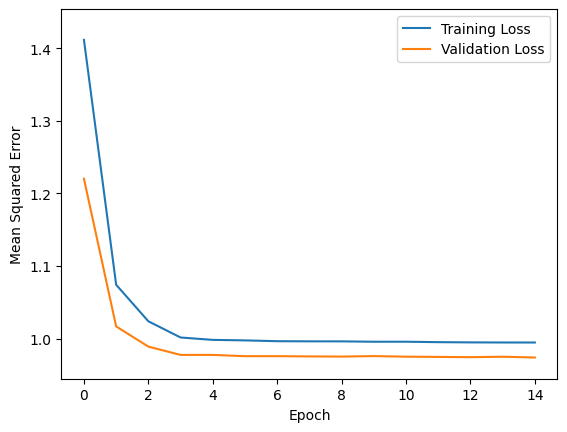

In [13]:
plt.figure()
plt.xlabel("Epoch")
plt.ylabel("Mean Squared Error")

plt.plot(epochs, mse, label="Training Loss")
plt.plot(epochs, history.history["val_mean_squared_error"], label="Validation Loss")

# mse_training is a pandas Series, so convert it to a list first.
merged_mse_lists = mse.tolist() + history.history["val_mean_squared_error"]
highest_loss = max(merged_mse_lists)
lowest_loss = min(merged_mse_lists)
top_of_y_axis = highest_loss * 1.03
bottom_of_y_axis = lowest_loss * 0.97

plt.ylim([bottom_of_y_axis, top_of_y_axis])
plt.legend()
plt.show()

-----

# Train a Neural Network

In [14]:
dense_output = tf.keras.layers.Dense(
    units=20,
    activation='relu',
    name='hidden_dense_layer_1')(preprocessing_layers)

# Create a Dense layer with 12 nodes.
dense_output = tf.keras.layers.Dense(
    units=12,
    activation='relu',
    name='hidden_dense_layer_2')(dense_output)

# Create the Dense output layer.
dense_output = tf.keras.layers.Dense(
    units=1,
    name='dense_output')(dense_output)

# Define an output dictionary we'll send to the model constructor.
outputs = {
'dense_output': dense_output
}

In [15]:
dnn_model = tf.keras.Model(inputs=inputs, outputs=outputs)
dnn_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=learning_rate),
    loss="mean_squared_error",
    metrics=[tf.keras.metrics.MeanSquaredError()]
)

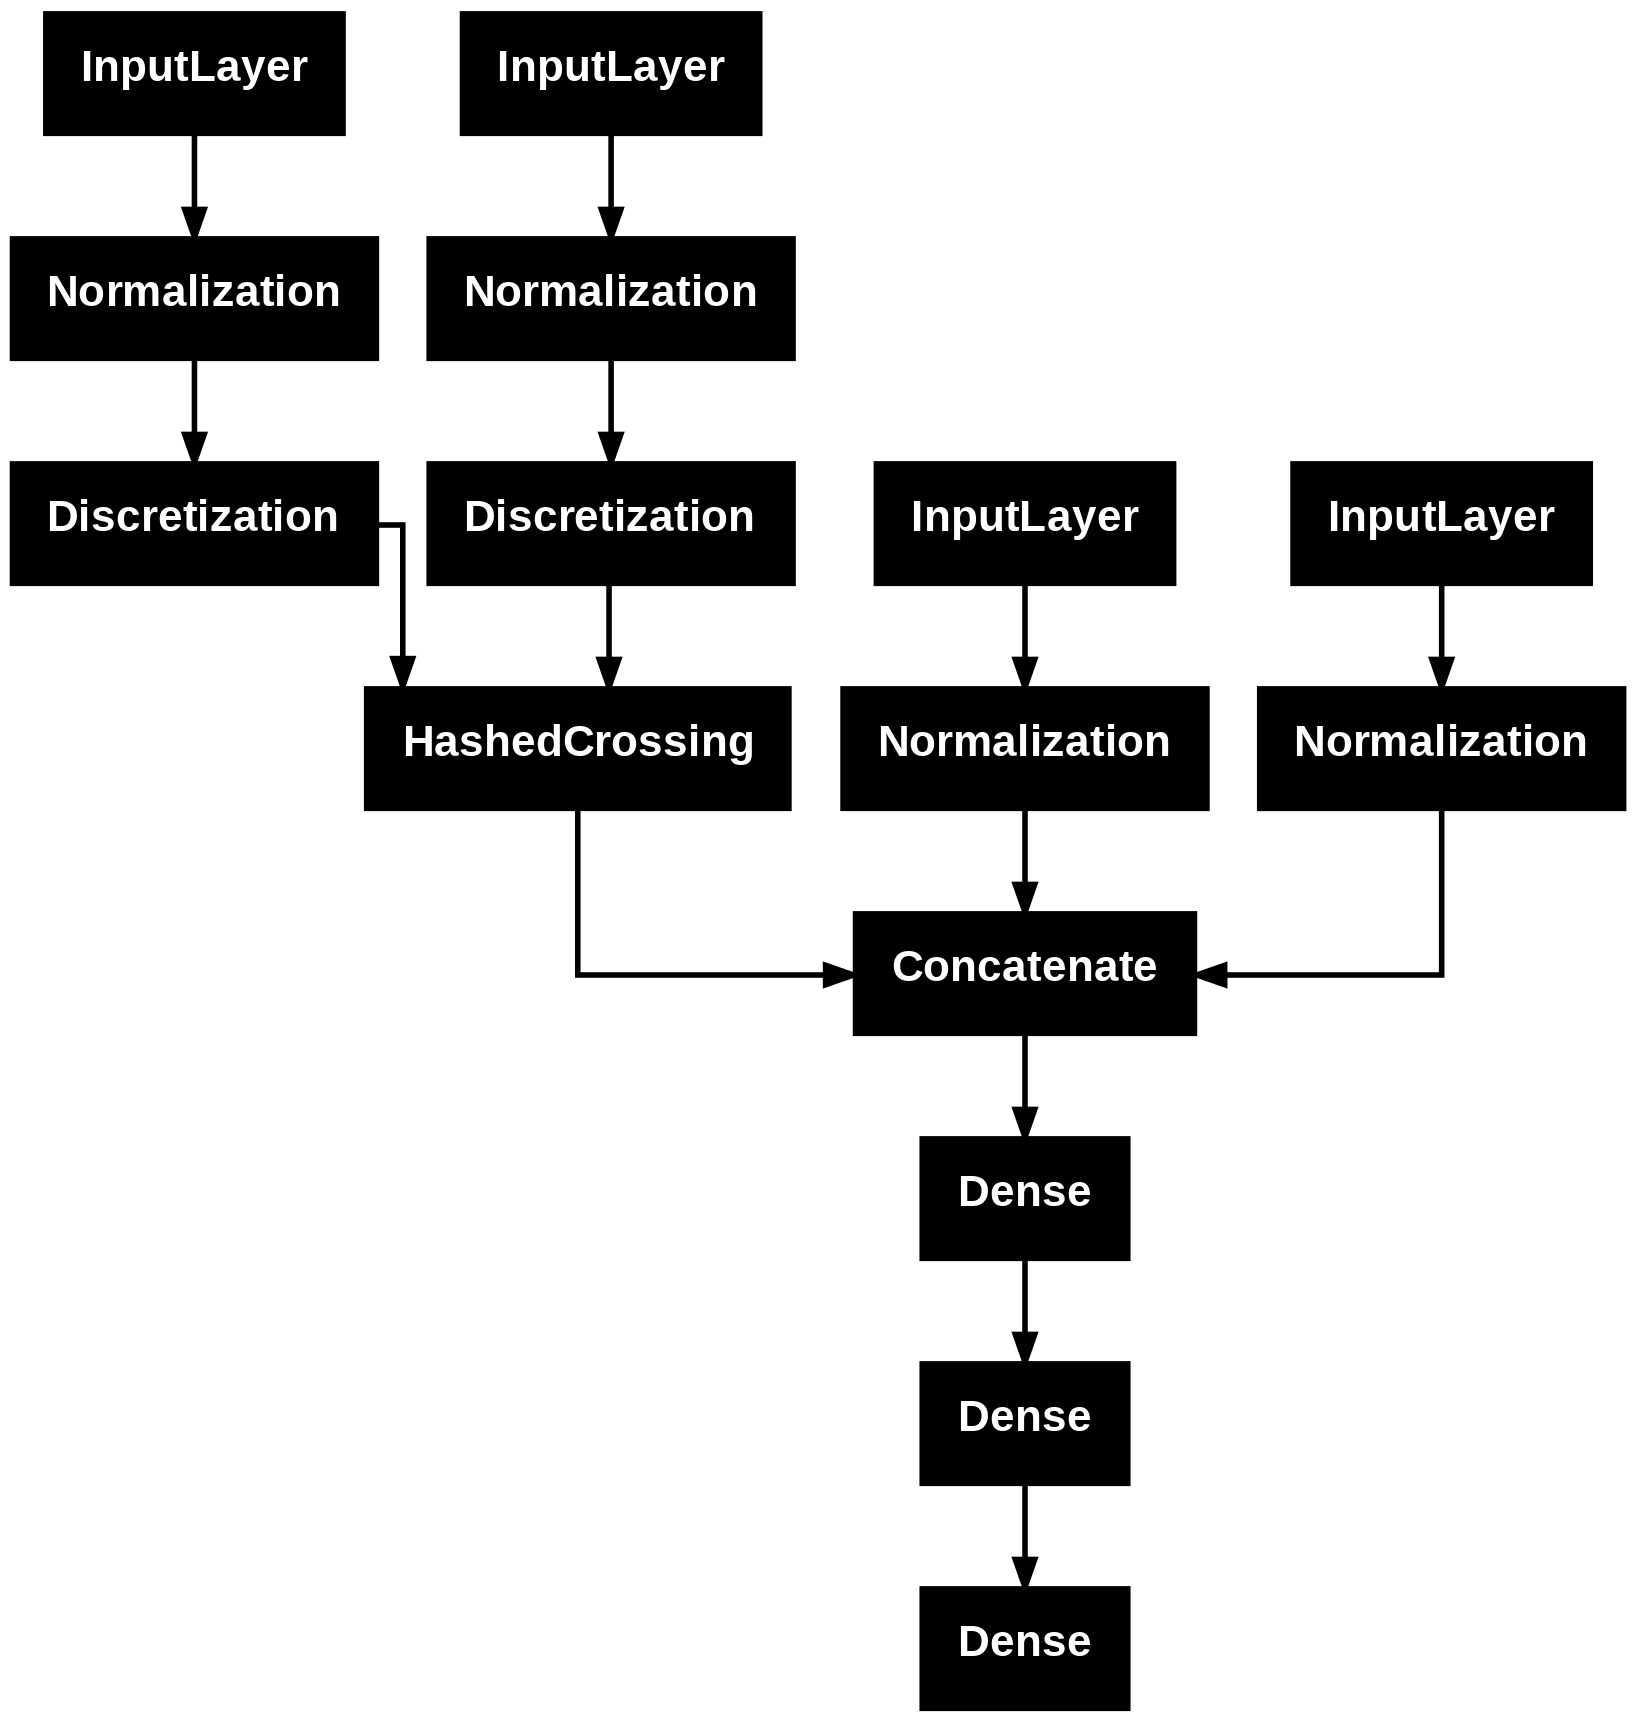

In [16]:
tf.keras.utils.plot_model(dnn_model)

In [17]:
learning_rate = 0.01
epochs = 15
batch_size = 1000
label_name = "median_house_value"

validation_split = 0.2

In [18]:
history = dnn_model.fit(
    x=features,
    y=label,
    batch_size=batch_size,
    epochs=epochs,
    shuffle=True,
    validation_split=validation_split)

# Get details that will be useful for plotting the loss curve.
epochs = history.epoch
hist = pd.DataFrame(history.history)
mse = hist["mean_squared_error"]

Epoch 1/15


/usr/local/lib/python3.12/dist-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: {'latitude': 'latitude', 'longitude': 'longitude', 'median_income': 'median_income', 'population': 'population'}
Received: inputs={'longitude': 'Tensor(shape=(None,))', 'latitude': 'Tensor(shape=(None,))', 'housing_median_age': 'Tensor(shape=(None,))', 'total_rooms': 'Tensor(shape=(None,))', 'total_bedrooms': 'Tensor(shape=(None,))', 'population': 'Tensor(shape=(None,))', 'households': 'Tensor(shape=(None,))', 'median_income': 'Tensor(shape=(None,))'}
  warnings.warn(msg)


14/14 ━━━━━━━━━━━━━━━━━━━━ 2s 44ms/step - loss: 1.1212 - mean_squared_error: 1.1212 - val_loss: 0.9938 - val_mean_squared_error: 0.9938
Epoch 2/15
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 1.0065 - mean_squared_error: 1.0065 - val_loss: 0.9825 - val_mean_squared_error: 0.9825
Epoch 3/15
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 1.0046 - mean_squared_error: 1.0046 - val_loss: 0.9813 - val_mean_squared_error: 0.9813
Epoch 4/15
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - loss: 1.0044 - mean_squared_error: 1.0044 - val_loss: 0.9806 - val_mean_squared_error: 0.9806
Epoch 5/15
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 1.0032 - mean_squared_error: 1.0032 - val_loss: 0.9817 - val_mean_squared_error: 0.9817
Epoch 6/15
14/14 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 1.0026 - mean_squared_error: 1.0026 - val_loss: 0.9814 - val_mean_squared_error: 0.9814
Epoch 7/15
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 1.0024 - mean_squared_error: 1.0024 - val_loss: 0.9802 - val_mean_squa

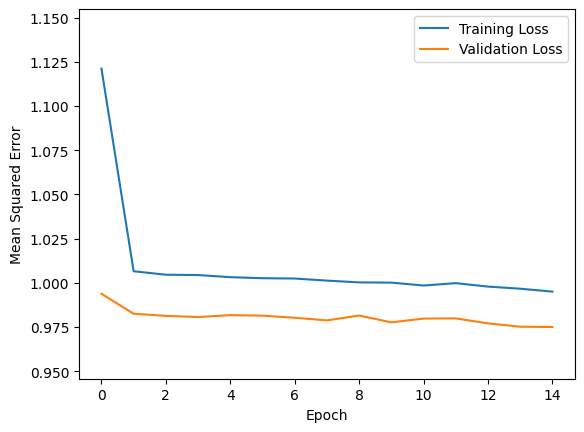

In [19]:
plt.figure()
plt.xlabel("Epoch")
plt.ylabel("Mean Squared Error")

plt.plot(epochs, mse, label="Training Loss")
plt.plot(epochs, history.history["val_mean_squared_error"], label="Validation Loss")

# mse_training is a pandas Series, so convert it to a list first.
merged_mse_lists = mse.tolist() + history.history["val_mean_squared_error"]
highest_loss = max(merged_mse_lists)
lowest_loss = min(merged_mse_lists)
top_of_y_axis = highest_loss * 1.03
bottom_of_y_axis = lowest_loss * 0.97

plt.ylim([bottom_of_y_axis, top_of_y_axis])
plt.legend()
plt.show()

In [20]:
# After building a model against the training set, test that model
# against the test set.
test_features = {name:np.array(value) for name, value in test_df.items()}
test_label = test_median_house_value_normalized(np.array(test_features.pop(label_name)))

print("\n Evaluate the new model against the test set:")
dnn_model.evaluate(
    x=test_features,
    y=test_label,
    batch_size=batch_size,
    return_dict=True)


 Evaluate the new model against the test set:
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.9932 - mean_squared_error: 0.9932


{'loss': 0.9931793808937073, 'mean_squared_error': 0.9931793808937073}

# Lab Exercise

The UCI Machine Learning Repo provides a dataset of about 4900 wine samplings from Portugual. The dataset includes physicochemical details about each wine sample (its acidity, sugar content, etc.) as well as sensory details (how the taster perceived its quality).

For this lab:

  1. Clean and preprocess your data:
      - Create a training dataset that includes at least 1 new engineered feature
      - Be sure to remove any outliers from your dataset as you go
  2. Define a feed-forward neural network
      - It should have at least 1 hidden layer, but may include more
          - How many neurons do you think each layer should include? Why?
          - What activation function(s) do you want to use in each layer?
      - The final output layer could be either a single neuron, if predicting the wine quality score as a regression task, or one or more neurons if predicting wine quality (poor, good, excellent) as a classification task
  3. Train your model and evaluate its performance between the training and validation samples
  4. Evaluate your model against the holdout testing dataset

In [21]:
!pip install ucimlrepo

In [22]:
from ucimlrepo import fetch_ucirepo


wine_quality = fetch_ucirepo(id=186)

X = wine_quality.data.features
y = wine_quality.data.targets

In [23]:
print(wine_quality.metadata)

{'uci_id': 186, 'name': 'Wine Quality', 'repository_url': 'https://archive.ics.uci.edu/dataset/186/wine+quality', 'data_url': 'https://archive.ics.uci.edu/static/public/186/data.csv', 'abstract': 'Two datasets are included, related to red and white vinho verde wine samples, from the north of Portugal. The goal is to model wine quality based on physicochemical tests (see [Cortez et al., 2009], http://www3.dsi.uminho.pt/pcortez/wine/).', 'area': 'Business', 'tasks': ['Classification', 'Regression'], 'characteristics': ['Multivariate'], 'num_instances': 4898, 'num_features': 11, 'feature_types': ['Real'], 'demographics': [], 'target_col': ['quality'], 'index_col': None, 'has_missing_values': 'no', 'missing_values_symbol': None, 'year_of_dataset_creation': 2009, 'last_updated': 'Wed Nov 15 2023', 'dataset_doi': '10.24432/C56S3T', 'creators': ['Paulo Cortez', 'A. Cerdeira', 'F. Almeida', 'T. Matos', 'J. Reis'], 'intro_paper': {'ID': 252, 'type': 'NATIVE', 'title': 'Modeling wine preferences

In [25]:
print(wine_quality.variables)

                name     role         type demographic  \
0      fixed_acidity  Feature   Continuous        None   
1   volatile_acidity  Feature   Continuous        None   
2        citric_acid  Feature   Continuous        None   
3     residual_sugar  Feature   Continuous        None   
4          chlorides  Feature   Continuous        None   
..               ...      ...          ...         ...   
8                 pH  Feature   Continuous        None   
9          sulphates  Feature   Continuous        None   
10           alcohol  Feature   Continuous        None   
11           quality   Target      Integer        None   
12             color    Other  Categorical        None   

               description units missing_values  
0                      NaN  None             no  
1                      NaN  None             no  
2                      NaN  None             no  
3                      NaN  None             no  
4                      NaN  None             no  
.. 